<a href="https://colab.research.google.com/github/poclab-web/molecular-color-explorer/blob/main/pyscf%E3%81%A7%E5%90%B8%E5%8F%8E%E6%B3%A2%E9%95%B7%E4%BA%88%E6%B8%AC_GDB17%E3%81%AE%E5%88%86%E5%AD%90%E4%BA%88%E6%B8%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 【1】インストール

In [10]:
!pip install rdkit pyscf pyscf-dftd3

## 【2】RDKit
- SMILES → InChIKey
- SMILES → RDKit 3D → XYZ 生成（MMFFで軽く最適化）

In [11]:
from rdkit import Chem

def smiles_to_inchikey(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.inchi.MolToInchiKey(mol)

In [12]:
from rdkit.Chem import AllChem

def smiles_to_xyz(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
    AllChem.MMFFOptimizeMolecule(mol)

    conf = mol.GetConformer()
    xyz_lines = []
    for i, atom in enumerate(mol.GetAtoms()):
        p = conf.GetAtomPosition(i)
        xyz_lines.append(f"{atom.GetSymbol()} {p.x:.6f} {p.y:.6f} {p.z:.6f}")
    return "\n".join(xyz_lines)

In [44]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

def get_structure_info(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    heavy = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() > 1)
    aromatic = rdMolDescriptors.CalcNumAromaticRings(mol)

    return heavy, aromatic

In [45]:
def structure_check(smiles: str, heavy_limit: int = 17):
    heavy, aromatic = get_structure_info(smiles)

    print(f"SMILES: {smiles}")
    print(f"Heavy atom count     : {heavy}")
    print(f"Aromatic ring count  : {aromatic}")

    if heavy > heavy_limit:
        print(f"⚠️ Heavy atom count が {heavy_limit} を超えています（heavy={heavy}）。計算を中止します。")
        return False, heavy, aromatic

    return True, heavy, aromatic

## 【3】PySCF TDDFT（構造最適化なし・垂直励起のみ）

In [13]:
import numpy as np
from pyscf import gto, dft, tdscf

HARTREE_TO_EV = 27.211386
EV_TO_NM = 1239.842

def tddft_vertical(xyz, charge=0, basis="def2-SVP", xc="CAM-B3LYP", nstates=8):
    # 電子数から spin を決定
    mol0 = gto.Mole(atom=xyz, basis=basis, charge=charge, spin=0, unit="Ang")
    mol0.build()
    ne = mol0.nelectron
    spin = 0 if ne % 2 == 0 else 1

    # 本計算用
    mol = gto.Mole(atom=xyz, basis=basis, charge=charge, spin=spin, unit="Ang", verbose=0)
    mol.build()

    # DFT（高速化: DF）
    if spin == 0:
        mf = dft.RKS(mol).density_fit()
    else:
        mf = dft.UKS(mol).density_fit()

    mf.xc = xc
    mf.grids.level = 1
    mf.kernel()

    # TDDFT / TDA
    if spin == 0:
        td = mf.TDA()            # 閉殻
    else:
        td = tdscf.UKS(mf)       # 開殻

    td.nstates = nstates
    td.kernel()

    e_ev = td.e * HARTREE_TO_EV
    wl_nm = EV_TO_NM / e_ev

    try:
        osc = td.oscillator_strength()
    except:
        osc = np.zeros_like(wl_nm)

    return wl_nm.tolist(), osc.tolist(), ne, spin


## 【4】電子状態の解析と結果の整理

### 禁制遷移を除外する（しきい値 f < 0.01）

In [14]:
def filter_forbidden_transitions(wavelengths_nm, osc_strength, threshold=0.01):
    wl2 = []
    f2 = []
    for wl, f in zip(wavelengths_nm, osc_strength):
        if f >= threshold:
            wl2.append(float(wl))
            f2.append(float(f))
    return wl2, f2


### **スペクトル** PNG を保存する関数

In [15]:
import matplotlib.pyplot as plt

def save_uv_spectrum_png(wavelengths_nm, osc_strength, png_path,
                         fwhm=15, resolution=0.2,
                         wl_min=100, wl_max=800):

    wl_grid = np.arange(wl_min, wl_max, resolution)
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    spectrum = np.zeros_like(wl_grid)

    for wl, f in zip(wavelengths_nm, osc_strength):
        spectrum += f * np.exp(-(wl_grid - wl)**2 / (2 * sigma**2))

    plt.figure(figsize=(8,4))
    plt.plot(wl_grid, spectrum, lw=2)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (a.u.)")
    plt.title("Simulated UV-Vis Spectrum")
    plt.xlim(wl_min, wl_max)
    plt.tight_layout()
    plt.savefig(png_path, dpi=200)
    plt.close()

In [26]:
import os
import json
import numpy as np
import pandas as pd

def summarize_results(base_dir="results"):
    """
    results/ の中にある InChIKey フォルダを走査し、
    各 JSON から以下を抽出して DataFrame にまとめる：

    - smiles
    - allowed_wavelength_nm の最大値（最大波長）
    - そのときの allowed_oscillator_strength
    - inchikey（フォルダ名 or JSON 内）
    - json_file（ファイル名）
    """
    rows = []

    for inchikey in os.listdir(base_dir):
        folder = os.path.join(base_dir, inchikey)
        if not os.path.isdir(folder):
            continue

        for fname in os.listdir(folder):
            if not fname.endswith(".json"):
                continue

            json_path = os.path.join(folder, fname)
            with open(json_path, "r") as f:
                data = json.load(f)

            smiles = data.get("smiles")
            wl = data.get("allowed_wavelength_nm") or []
            osc = data.get("allowed_oscillator_strength") or []

            # allowed が空なら skip
            if not wl or not osc:
                continue

            wl_arr = np.array(wl, dtype=float)
            osc_arr = np.array(osc, dtype=float)

            # 最も長波長の遷移を採用
            idx = int(np.argmax(wl_arr))

            rows.append({
                "inchikey": data.get("inchikey", inchikey),
                "smiles": smiles,
                "lambda_max_nm": wl_arr[idx],
                "osc_at_lambda_max": osc_arr[idx],
            })

    df = pd.DataFrame(rows)

    # λmax の降順にして見やすく
    if not df.empty:
        df = df.sort_values("lambda_max_nm", ascending=False).reset_index(drop=True)

    return df


## 【5】2次元マップ化

In [55]:
import os
import json
import numpy as np
import pandas as pd

def summarize_results(base_dir="results"):
    """
    results/ 以下の InChIKey フォルダにある JSON を走査して、
    各 JSON から以下を抽出し DataFrame にまとめる：

      - smiles
      - lambda_max_nm（allowed の最大波長）
      - osc_at_lambda_max
      - compute_time_sec（計算時間）
    """
    rows = []

    for inchikey in os.listdir(base_dir):
        folder = os.path.join(base_dir, inchikey)
        if not os.path.isdir(folder):
            continue

        for fname in os.listdir(folder):
            if not fname.endswith(".json"):
                continue

            json_path = os.path.join(folder, fname)
            with open(json_path, "r") as f:
                data = json.load(f)

            smiles = data.get("smiles")
            wl = data.get("allowed_wavelength_nm") or []
            osc = data.get("allowed_oscillator_strength") or []
            compute_time = data.get("compute_time_sec", None)   # ← 追加

            # allowed_wavelength_nm が空ならスキップ
            if not wl or not osc:
                continue

            wl_arr = np.array(wl, dtype=float)
            osc_arr = np.array(osc, dtype=float)

            # 最長波長のインデックス
            idx = int(np.argmax(wl_arr))

            rows.append({
                "inchikey": data.get("inchikey", inchikey),
                "json_file": fname,
                "smiles": smiles,
                "lambda_max_nm": wl_arr[idx],
                "osc_at_lambda_max": osc_arr[idx],
                "compute_time_sec": compute_time,   # ← 追加
            })

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values("lambda_max_nm", ascending=False).reset_index(drop=True)

    return df

In [31]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

def calc_heavy_atom_count(smiles: str) -> int:
    """H を除いた原子数（heavy atoms）を返す。"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() > 1)

def calc_aromatic_ring_count(smiles: str) -> int:
    """芳香環の数を返す（RDKit の aromatic ring 数）。"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return rdMolDescriptors.CalcNumAromaticRings(mol)

def add_structure_axes(df: pd.DataFrame) -> pd.DataFrame:
    """
    DataFrame に
      - heavy_atom_count（横軸）
      - aromatic_ring_count（縦軸）
    の列を追加して返す。
    """
    df = df.copy()
    df["heavy_atom_count"] = df["smiles"].apply(calc_heavy_atom_count)
    df["aromatic_ring_count"] = df["smiles"].apply(calc_aromatic_ring_count)
    # 計算失敗などを除外
    df = df.dropna(subset=["heavy_atom_count", "aromatic_ring_count", "lambda_max_nm"])
    return df


In [32]:
import matplotlib.pyplot as plt

def plot_structure_map(df: pd.DataFrame, out_png: str | None = None):
    """
    横軸: heavy_atom_count
    縦軸: aromatic_ring_count
    色  : lambda_max_nm
    の 2D マップをプロット。
    out_png を指定するとファイルとして保存。
    """
    if df.empty:
        print("DataFrame が空です。先に summarize_results を確認してください。")
        return

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        df["heavy_atom_count"],
        df["aromatic_ring_count"],
        c=df["lambda_max_nm"],
        cmap="jet",
        s=60,
        edgecolors="k",
        linewidths=0.5,
    )
    cbar = plt.colorbar(sc)
    cbar.set_label("λmax (nm)")

    plt.xlabel("Heavy atom count")
    plt.ylabel("Aromatic ring count")
    plt.title("Structure Map colored by λmax")

    plt.grid(alpha=0.3)
    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=200)
        print(f"Saved structure map to: {out_png}")
    plt.show()


In [33]:
def build_structure_map(base_dir="results", out_png="structure_map.png"):
    """
    1. results/ 以下の JSON を集計して λmax を取り出し
    2. SMILES から heavy_atom_count / aromatic_ring_count を計算
    3. 2D マップを描き、PNG も保存
    4. 最終的な DataFrame を返す
    """
    df = summarize_results(base_dir=base_dir)
    if df.empty:
        print("No data found under:", base_dir)
        return df

    df = add_structure_axes(df)
    if df.empty:
        print("構造情報の計算に失敗しました。SMILES を確認してください。")
        return df

    plot_structure_map(df, out_png=out_png)
    return df


## 【6】ワークフロー
- 【2】から【4】を一括して行う

In [51]:
import os
import json
import time  # ← 計算時間測定に必要

def save_result_with_png(smiles, charge=0):
    # ===============================
    #  計算開始時刻
    # ===============================
    start_time = time.time()

    # --- InChIKey ---
    inchikey = smiles_to_inchikey(smiles)

    # --- フォルダ作成 ---
    folder = f"results/{inchikey}"
    os.makedirs(folder, exist_ok=True)

    # --- RDKit 3D ---
    xyz = smiles_to_xyz(smiles)

    # --- TDDFT（垂直励起）---
    wl_all, f_all, ne, spin = tddft_vertical(xyz, charge=charge)

    # --- 禁制遷移除外 ---
    wl_allowed, f_allowed = filter_forbidden_transitions(wl_all, f_all)

    # --- λmax ---
    if len(f_allowed) > 0:
        idx = int(np.argmax(f_allowed))
        lambda_max = wl_allowed[idx]
    else:
        lambda_max = None

    # ===============================
    #  計算時間を測定
    # ===============================
    end_time = time.time()
    elapsed_sec = end_time - start_time
    elapsed_sec = float(elapsed_sec)

    print(f"計算時間: {elapsed_sec:.2f} 秒")

    # --- JSON 保存 ---
    result = {
        "smiles": smiles,
        "inchikey": inchikey,
        "electron_count": ne,
        "spin": spin,
        "lambda_max_nm": lambda_max,
        "all_wavelength_nm": wl_all,
        "oscillator_strength": f_all,
        "allowed_wavelength_nm": wl_allowed,
        "allowed_oscillator_strength": f_allowed,
        "compute_time_sec": elapsed_sec   # ← 追加！
    }

    json_path = f"{folder}/{inchikey}.json"
    with open(json_path, "w") as f:
        json.dump(result, f, indent=2)

    # --- PNG 保存 ---
    png_path = f"{folder}/{inchikey}.png"
    save_uv_spectrum_png(
        wl_allowed if len(wl_allowed)>0 else wl_all,
        f_allowed if len(f_allowed)>0 else f_all,
        png_path
    )

    print(f"Saved JSON: {json_path}")
    print(f"Saved PNG:  {png_path}")

    return result, json_path, png_path

## 入力して計算する部分

In [52]:
input_SMILES = "CCC"


# ① 構造チェック（heavy atom count / aromatic ring count の表示）
ok, heavy, aromatic = structure_check(input_SMILES)

# ② heavy atom count に問題なければ計算を実行
if ok:
    result, json_path, png_path = save_result_with_png(input_SMILES)
    result


SMILES: CCC
Heavy atom count     : 3
Aromatic ring count  : 0
計算時間: 52.28 秒
Saved JSON: results/ATUOYWHBWRKTHZ-UHFFFAOYSA-N/ATUOYWHBWRKTHZ-UHFFFAOYSA-N.json
Saved PNG:  results/ATUOYWHBWRKTHZ-UHFFFAOYSA-N/ATUOYWHBWRKTHZ-UHFFFAOYSA-N.png


,inchikey,json_file,smiles,lambda_max_nm,osc_at_lambda_max,compute_time_sec,Mol
0,UFWIBTONFRDIAS-UHFFFAOYSA-N,UFWIBTONFRDIAS-UHFFFAOYSA-N.json,c1ccc2ccccc2c1,260.759050,0.123568,NaN,
1,LQNUZADURLCDLV-UHFFFAOYSA-N,LQNUZADURLCDLV-UHFFFAOYSA-N.json,c1ccc(cc1)[N+](=O)[O-],249.096704,0.020962,NaN,
2,UHOVQNZJYSORNB-UHFFFAOYSA-N,UHOVQNZJYSORNB-UHFFFAOYSA-N.json,c1ccccc1,153.867060,1.006941,NaN,
3,VGGSQFUCUMXWEO-UHFFFAOYSA-N,VGGSQFUCUMXWEO-UHFFFAOYSA-N.json,C=C,140.988822,0.612633,NaN,
4,ATUOYWHBWRKTHZ-UHFFFAOYSA-N,ATUOYWHBWRKTHZ-UHFFFAOYSA-N.json,CCC,123.204321,0.050219,52.27941,
5,VNWKTOKETHGBQD-UHFFFAOYSA-N,VNWKTOKETHGBQD-UHFFFAOYSA-N.json,C,105.873985,0.199139,NaN,
6,OTMSDBZUPAUEDD-UHFFFAOYSA-N,OTMSDBZUPAUEDD-UHFFFAOYSA-N.json,CC,105.516429,0.202779,NaN,

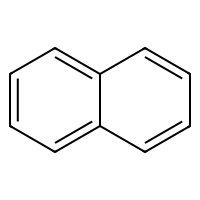
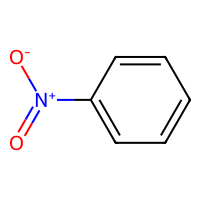
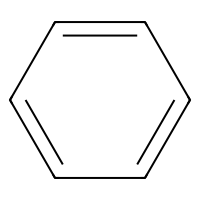
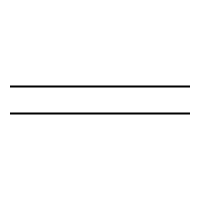
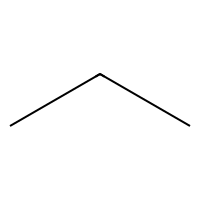
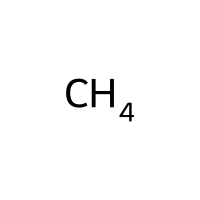
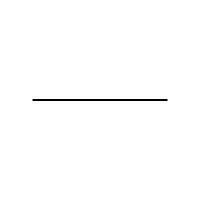

In [56]:
df = summarize_results("results")

from rdkit.Chem import PandasTools
PandasTools.AddMoleculeColumnToFrame(df, smilesCol="smiles", molCol="Mol")
df

Saved structure map to: structure_map.png


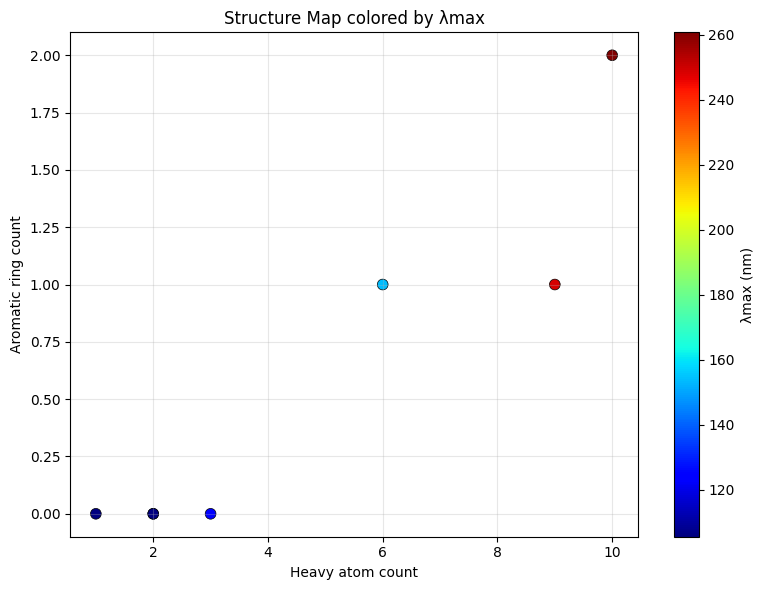

,inchikey,json_file,smiles,lambda_max_nm,osc_at_lambda_max,heavy_atom_count,aromatic_ring_count
0,UFWIBTONFRDIAS-UHFFFAOYSA-N,UFWIBTONFRDIAS-UHFFFAOYSA-N.json,c1ccc2ccccc2c1,260.759050,0.123568,10,2
1,LQNUZADURLCDLV-UHFFFAOYSA-N,LQNUZADURLCDLV-UHFFFAOYSA-N.json,c1ccc(cc1)[N+](=O)[O-],249.096704,0.020962,9,1
2,UHOVQNZJYSORNB-UHFFFAOYSA-N,UHOVQNZJYSORNB-UHFFFAOYSA-N.json,c1ccccc1,153.867060,1.006941,6,1
3,VGGSQFUCUMXWEO-UHFFFAOYSA-N,VGGSQFUCUMXWEO-UHFFFAOYSA-N.json,C=C,140.988822,0.612633,2,0
4,ATUOYWHBWRKTHZ-UHFFFAOYSA-N,ATUOYWHBWRKTHZ-UHFFFAOYSA-N.json,CCC,123.204321,0.050219,3,0


In [54]:
df_map = build_structure_map(base_dir="results", out_png="structure_map.png")
df_map.head()

In [57]:
# resultsフォルダのダウンロード

!zip -r results.zip results

from google.colab import files
files.download("results.zip")

  adding: results/ (stored 0%)
  adding: results/VNWKTOKETHGBQD-UHFFFAOYSA-N/ (stored 0%)
  adding: results/VNWKTOKETHGBQD-UHFFFAOYSA-N/VNWKTOKETHGBQD-UHFFFAOYSA-N.json (deflated 56%)
  adding: results/VNWKTOKETHGBQD-UHFFFAOYSA-N/VNWKTOKETHGBQD-UHFFFAOYSA-N.png (deflated 20%)
  adding: results/LQNUZADURLCDLV-UHFFFAOYSA-N/ (stored 0%)
  adding: results/LQNUZADURLCDLV-UHFFFAOYSA-N/LQNUZADURLCDLV-UHFFFAOYSA-N.png (deflated 14%)
  adding: results/LQNUZADURLCDLV-UHFFFAOYSA-N/LQNUZADURLCDLV-UHFFFAOYSA-N.json (deflated 56%)
  adding: results/PAYRUJLWNCNPSJ-UHFFFAOYSA-N/ (stored 0%)
  adding: results/UHOVQNZJYSORNB-UHFFFAOYSA-N/ (stored 0%)
  adding: results/UHOVQNZJYSORNB-UHFFFAOYSA-N/UHOVQNZJYSORNB-UHFFFAOYSA-N.png (deflated 17%)
  adding: results/UHOVQNZJYSORNB-UHFFFAOYSA-N/UHOVQNZJYSORNB-UHFFFAOYSA-N.json (deflated 53%)
  adding: results/OTMSDBZUPAUEDD-UHFFFAOYSA-N/ (stored 0%)
  adding: results/OTMSDBZUPAUEDD-UHFFFAOYSA-N/OTMSDBZUPAUEDD-UHFFFAOYSA-N.png (deflated 18%)
  adding: results/OT

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>